# Практическая работа №2  
## Первоначальная обработка сетевого трафика на примере **UNSW-NB15**
## Железняков Родион Алексеевич ББМО-01-25
**Цель:** получить структурированный, очищенный и нормализованный датасет для задач IDS/IPS и сравнить две стратегии балансировки классов: **SMOTE** и **Random UnderSampling**.

В этой работе используется **альтернативный датасет UNSW-NB15**, как и требуется в задании. Ноутбук включает:

- загрузку и первичный осмотр данных;
- удаление дубликатов;
- обработку пропусков, `Infinity` и невалидных значений;
- обнаружение и удаление выбросов методом **IQR**;
- кодирование категориальных признаков через **One-Hot Encoding**;
- нормализацию числовых признаков через **StandardScaler**;
- сравнение **SMOTE** и простого андерсэмплинга;
- визуализацию распределения классов до и после балансировки;
- финальную сборку обучающего датасета.

> Важный принцип: любые операции, которые могут привести к утечке данных, выполняются **только на обучающей выборке**.


## 1. Подготовка окружения

Если библиотека `imbalanced-learn` не установлена, раскомментируйте следующую строку.


In [1]:
# !pip install -q imbalanced-learn

In [2]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 30)


## 2. Загрузка датасета

Используем официальный альтернативный датасет **UNSW-NB15**.  
Ниже предусмотрена автоматическая загрузка train/test CSV-файлов, если их нет локально.


In [4]:
DATA_DIR = Path("data_unsw_nb15")
DATA_DIR.mkdir(exist_ok=True)

TRAIN_PATH = DATA_DIR / "UNSW_NB15_training-set.csv"
TEST_PATH = DATA_DIR / "UNSW_NB15_testing-set.csv"

TRAIN_URL = "https://raw.githubusercontent.com/Nir-J/ML-Projects/master/UNSW-Network_Packet_Classification/UNSW_NB15_training-set.csv"
TEST_URL = "https://raw.githubusercontent.com/Nir-J/ML-Projects/master/UNSW-Network_Packet_Classification/UNSW_NB15_testing-set.csv"

if not TRAIN_PATH.exists():
    train_df = pd.read_csv(TRAIN_URL)
    train_df.to_csv(TRAIN_PATH, index=False)
else:
    train_df = pd.read_csv(TRAIN_PATH)

if not TEST_PATH.exists():
    test_df = pd.read_csv(TEST_URL)
    test_df.to_csv(TEST_PATH, index=False)
else:
    test_df = pd.read_csv(TEST_PATH)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)


Train shape: (175341, 45)
Test shape : (82332, 45)


## 3. Первичный осмотр

Посмотрим на структуру данных, типы признаков и целевую переменную.


In [5]:
display(train_df.head())
display(train_df.info())
display(train_df.describe(include="all").T.head(20))


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,252,254,14158.942380,8495.365234,0,0,24.295600,8.375000,30.177547,11.830604,255,621772692,2202533631,255,0.000000,0.000000,0.000000,43,43,0,0,1,0,1,1,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,62,252,8395.112305,503571.312500,2,17,49.915000,15.432865,61.426934,1387.778330,255,1417884146,3077387971,255,0.000000,0.000000,0.000000,52,1106,0,0,43,1,1,1,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,62,252,1572.271851,60929.230470,1,6,231.875571,102.737203,17179.586860,11420.926230,255,2116150707,2963114973,255,0.111897,0.061458,0.050439,46,824,0,0,7,1,2,1,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,62,252,2740.178955,3358.622070,1,3,152.876547,90.235726,259.080172,4991.784669,255,1107119177,1047442890,255,0.000000,0.000000,0.000000,52,64,0,0,1,1,2,1,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,254,252,8561.499023,3987.059814,2,1,47.750333,75.659602,2415.837634,115.807000,255,2436137549,1977154190,255,0.128381,0.071147,0.057234,53,45,0,0,43,1,2,2,1,40,0,0,0,2,39,0,Normal,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 175341 non-null  int64  
 1   dur                175341 non-null  float64
 2   proto              175341 non-null  object 
 3   service            175341 non-null  object 
 4   state              175341 non-null  object 
 5   spkts              175341 non-null  int64  
 6   dpkts              175341 non-null  int64  
 7   sbytes             175341 non-null  int64  
 8   dbytes             175341 non-null  int64  
 9   rate               175341 non-null  float64
 10  sttl               175341 non-null  int64  
 11  dttl               175341 non-null  int64  
 12  sload              175341 non-null  float64
 13  dload              175341 non-null  float64
 14  sloss              175341 non-null  int64  
 15  dloss              175341 non-null  int64  
 16  si

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,175341.0,NaN,NaN,NaN,87671.0,50616.731112,1.0,43836.0,87671.0,131506.0,175341.0
dur,175341.0,NaN,NaN,NaN,1.359389,6.480249,0.0,0.000008,0.001582,0.668069,59.999989
proto,175341,133,tcp,79946,NaN,NaN,NaN,NaN,NaN,NaN,NaN
service,175341,13,-,94168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,175341,9,INT,82275,NaN,NaN,NaN,NaN,NaN,NaN,NaN
spkts,175341.0,NaN,NaN,NaN,20.298664,136.887597,1.0,2.0,2.0,12.0,9616.0
dpkts,175341.0,NaN,NaN,NaN,18.969591,110.258271,0.0,0.0,2.0,10.0,10974.0
sbytes,175341.0,NaN,NaN,NaN,8844.843836,174765.644309,28.0,114.0,430.0,1418.0,12965233.0
dbytes,175341.0,NaN,NaN,NaN,14928.918564,143654.217718,0.0,0.0,164.0,1102.0,14655550.0
rate,175341.0,NaN,NaN,NaN,95406.187105,165400.978457,0.0,32.78614,3225.80652,125000.0003,1000000.003


In [6]:
print("Столбцы train:")
print(list(train_df.columns))


Столбцы train:
['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']


В UNSW-NB15 обычно используются:

- `label` — бинарная целевая переменная: `0` — нормальный трафик, `1` — атака;
- `attack_cat` — категория атаки;
- часть признаков числовые, часть категориальные (`proto`, `service`, `state`).

Для данной работы основной целевой переменной будет **`label`**.


In [7]:
TARGET = "label"
AUXILIARY_DROP = ["attack_cat"]  # не используем как признак, чтобы не подсказывать модели тип атаки

full_df = pd.concat([train_df, test_df], ignore_index=True)
print("Объединённый датасет:", full_df.shape)

print("\nРаспределение классов:")
display(full_df[TARGET].value_counts())
display((full_df[TARGET].value_counts(normalize=True) * 100).round(2))


Объединённый датасет: (257673, 45)

Распределение классов:


label
1    164673
0     93000
Name: count, dtype: int64

label
1    63.91
0    36.09
Name: proportion, dtype: float64

## 4. Удаление дубликатов

Дубликаты искажают распределение трафика и могут завысить качество будущей модели.  
Удалим полные дубликаты строк.


In [8]:
rows_before = len(full_df)
full_df = full_df.drop_duplicates().reset_index(drop=True)
rows_after = len(full_df)

print(f"Удалено дубликатов: {rows_before - rows_after}")
print(f"Размер датасета после удаления дубликатов: {full_df.shape}")


Удалено дубликатов: 0
Размер датасета после удаления дубликатов: (257673, 45)


## 5. Очистка мусорных значений и пропусков

В сетевых логах часто встречаются:
- пропуски `NaN`;
- бесконечности `Infinity`, `-Infinity`;
- текстовые артефакты.

Сначала заменим бесконечности на `NaN`, затем оценим объём пропусков.


In [9]:
full_df = full_df.replace([np.inf, -np.inf], np.nan)

missing_stats = (
    full_df.isna().sum()
    .sort_values(ascending=False)
    .to_frame("missing_count")
)
missing_stats["missing_percent"] = (missing_stats["missing_count"] / len(full_df) * 100).round(3)

display(missing_stats[missing_stats["missing_count"] > 0].head(20))


,missing_count,missing_percent


Здесь мы **не удаляем все строки с пропусками**, потому что в IDS-задачах среди них могут находиться редкие атакующие примеры.  
Вместо этого пропуски будут заполняться в пайплайне:

- для числовых признаков — **медианой**;
- для категориальных — наиболее частым значением.


## 6. Разделение на признаки и целевую переменную

После удаления дубликатов делим данные на `X` и `y`. Затем выполняем стратифицированное разделение на train/test.


In [10]:
X = full_df.drop(columns=[TARGET] + [c for c in AUXILIARY_DROP if c in full_df.columns])
y = full_df[TARGET].astype(int)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train_raw:", X_train_raw.shape)
print("X_test_raw :", X_test_raw.shape)
print("y_train distribution:")
display(y_train.value_counts())


X_train_raw: (206138, 43)
X_test_raw : (51535, 43)
y_train distribution:


label
1    131738
0     74400
Name: count, dtype: int64

## 7. Обнаружение и удаление выбросов методом IQR

Требование задания — самостоятельно реализовать обработку выбросов.  
Чтобы не вносить утечку данных, границы IQR вычисляем **только на обучающей выборке**.

Важно: выбросы удаляем только по числовым признакам и только в train.


In [11]:
numeric_cols = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_train_raw.select_dtypes(exclude=[np.number]).columns.tolist()

print("Числовых признаков:", len(numeric_cols))
print("Категориальных признаков:", len(categorical_cols))
print("Категориальные признаки:", categorical_cols)


Числовых признаков: 40
Категориальных признаков: 3
Категориальные признаки: ['proto', 'service', 'state']


In [12]:
def iqr_filter(df, numeric_columns, k=1.5):
    df_num = df[numeric_columns].copy()

    q1 = df_num.quantile(0.25)
    q3 = df_num.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - k * iqr
    upper_bound = q3 + k * iqr

    mask = ~((df_num < lower_bound) | (df_num > upper_bound)).any(axis=1)
    return mask, lower_bound, upper_bound

train_mask, lower_bound, upper_bound = iqr_filter(X_train_raw, numeric_cols, k=1.5)

X_train_iqr = X_train_raw.loc[train_mask].copy()
y_train_iqr = y_train.loc[train_mask].copy()

print("До удаления выбросов:", X_train_raw.shape)
print("После удаления выбросов:", X_train_iqr.shape)
print("Удалено строк:", X_train_raw.shape[0] - X_train_iqr.shape[0])


До удаления выбросов: (206138, 43)
После удаления выбросов: (45724, 43)
Удалено строк: 160414


Замечание: IQR-очистка в IDS-задачах должна применяться осторожно.  
Слишком агрессивное удаление выбросов может удалить и редкие атаки, которые как раз и являются важным сигналом.


## 8. Визуализация дисбаланса классов до балансировки


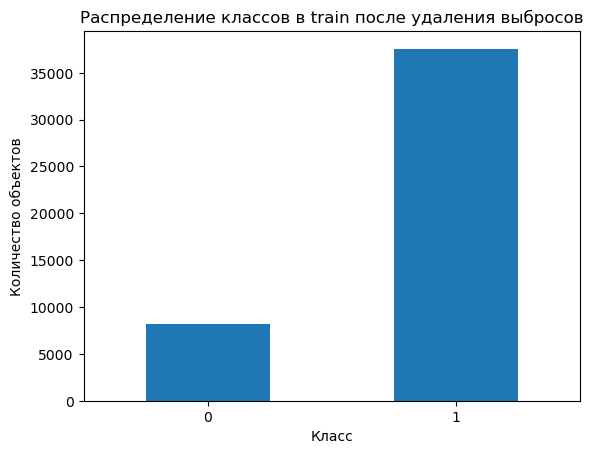

,count
label,
0,8167
1,37557


In [13]:
def plot_class_distribution(y_values, title):
    counts = pd.Series(y_values).value_counts().sort_index()
    ax = counts.plot(kind="bar")
    ax.set_title(title)
    ax.set_xlabel("Класс")
    ax.set_ylabel("Количество объектов")
    plt.xticks(rotation=0)
    plt.show()
    display(counts.to_frame("count"))

plot_class_distribution(y_train_iqr, "Распределение классов в train после удаления выбросов")


## 9. One-Hot Encoding и нормализация

Почему не `LabelEncoder` для категориальных признаков:

`LabelEncoder` создаёт ложный порядок значений, например `TCP=0`, `UDP=1`, `ICMP=2`, из-за чего модель может ошибочно считать, что между протоколами есть числовая иерархия.  
Поэтому используем **One-Hot Encoding**.

Для числовых признаков применяем:
- заполнение пропусков медианой;
- `StandardScaler`.


In [14]:
try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", encoder)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ],
    remainder="drop"
)


In [15]:
X_train_prepared = preprocessor.fit_transform(X_train_iqr)
X_test_prepared = preprocessor.transform(X_test_raw)

X_train_prepared = np.asarray(X_train_prepared, dtype=np.float32)
X_test_prepared = np.asarray(X_test_prepared, dtype=np.float32)

print("Подготовленный train:", X_train_prepared.shape)
print("Подготовленный test :", X_test_prepared.shape)


Подготовленный train: (45724, 183)
Подготовленный test : (51535, 183)


## 10. Балансировка классов

Требование задания: сравнить:
1. **SMOTE**
2. **простой андерсэмплинг большинства**

Обе операции выполняются **только на train**.


In [16]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_prepared, y_train_iqr)

rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train_prepared, y_train_iqr)

print("После SMOTE:", X_train_smote.shape, pd.Series(y_train_smote).value_counts().to_dict())
print("После RandomUnderSampler:", X_train_rus.shape, pd.Series(y_train_rus).value_counts().to_dict())


После SMOTE: (75114, 183) {1: 37557, 0: 37557}
После RandomUnderSampler: (16334, 183) {0: 8167, 1: 8167}


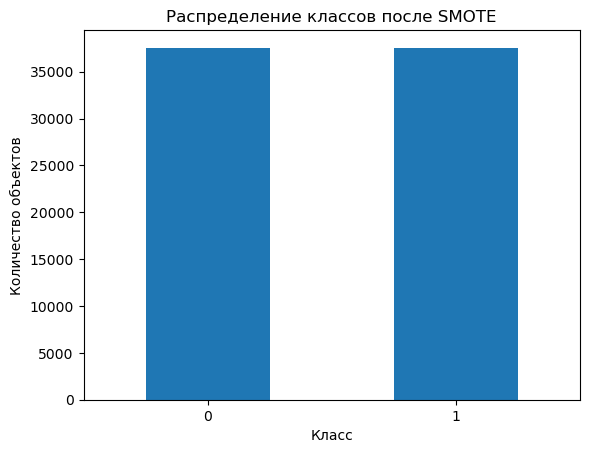

,count
label,
0,37557
1,37557


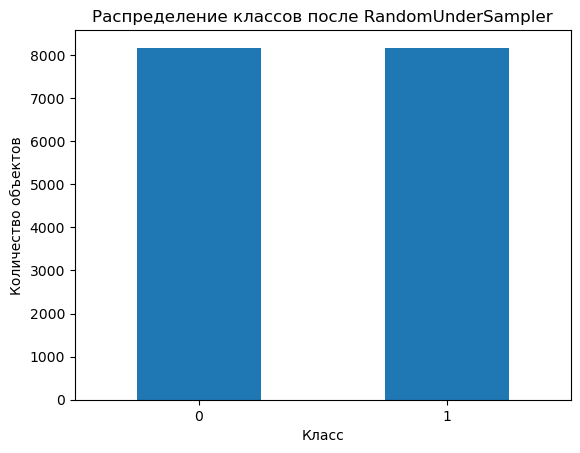

,count
label,
0,8167
1,8167


In [17]:
plot_class_distribution(y_train_smote, "Распределение классов после SMOTE")
plot_class_distribution(y_train_rus, "Распределение классов после RandomUnderSampler")


## 11. Финальная сборка датасета

Соберём итоговые таблицы, которые уже можно использовать для обучения моделей машинного обучения.  
Сохраним три варианта:

- `train_prepared` — очищенный и нормализованный train без балансировки;
- `train_smote` — train после SMOTE;
- `train_rus` — train после андерсэмплинга;
- `test_prepared` — тестовая выборка без изменения распределения классов.


In [18]:
feature_names = preprocessor.get_feature_names_out()

train_prepared_df = pd.DataFrame(X_train_prepared, columns=feature_names)
train_prepared_df[TARGET] = y_train_iqr.reset_index(drop=True).values

train_smote_df = pd.DataFrame(X_train_smote, columns=feature_names)
train_smote_df[TARGET] = pd.Series(y_train_smote).reset_index(drop=True).values

train_rus_df = pd.DataFrame(X_train_rus, columns=feature_names)
train_rus_df[TARGET] = pd.Series(y_train_rus).reset_index(drop=True).values

test_prepared_df = pd.DataFrame(X_test_prepared, columns=feature_names)
test_prepared_df[TARGET] = y_test.reset_index(drop=True).values

print("train_prepared_df:", train_prepared_df.shape)
print("train_smote_df   :", train_smote_df.shape)
print("train_rus_df     :", train_rus_df.shape)
print("test_prepared_df :", test_prepared_df.shape)


train_prepared_df: (45724, 184)
train_smote_df   : (75114, 184)
train_rus_df     : (16334, 184)
test_prepared_df : (51535, 184)


In [19]:
OUTPUT_DIR = Path("processed_unsw_nb15")
OUTPUT_DIR.mkdir(exist_ok=True)

train_prepared_df.to_csv(OUTPUT_DIR / "train_prepared.csv", index=False)
train_smote_df.to_csv(OUTPUT_DIR / "train_smote.csv", index=False)
train_rus_df.to_csv(OUTPUT_DIR / "train_rus.csv", index=False)
test_prepared_df.to_csv(OUTPUT_DIR / "test_prepared.csv", index=False)

print("Файлы сохранены в папку:", OUTPUT_DIR.resolve())


Файлы сохранены в папку: C:\Users\ro517\Рабочий стол\Univer\МАГ ИБ\mag_study\Теория обнаружения вторжений с применением ИИ\processed_unsw_nb15


## 12. Краткие выводы для отчёта

### Что было сделано
1. Загружен альтернативный IDS-датасет **UNSW-NB15**.
2. Выполнен первичный осмотр признаков и целевой переменной.
3. Удалены полные дубликаты строк.
4. Обработаны невалидные значения (`NaN`, `Infinity`).
5. Реализовано обнаружение и удаление выбросов методом **IQR**.
6. Выполнено кодирование категориальных признаков через **One-Hot Encoding**.
7. Выполнена нормализация числовых признаков через **StandardScaler**.
8. Сравнены две стратегии балансировки: **SMOTE** и **RandomUnderSampler**.
9. Сформированы и сохранены итоговые наборы данных для дальнейшего обучения модели.

### Почему нельзя просто удалять все «ненормальные» строки
Потому что среди них могут оказаться редкие образцы атак. Если удалить их без анализа, модель будет хуже распознавать угрозы и ещё сильнее сместится в сторону нормального трафика.

### Когда SMOTE может навредить
SMOTE может генерировать синтетические точки в областях, где классы пересекаются. В IDS-задачах это опасно тем, что синтетические атаки могут оказаться слишком близко к нормальному трафику и добавить шум.

### Почему нельзя использовать LabelEncoder для категориальных признаков
Потому что он создаёт искусственный числовой порядок категорий. Для сетевых протоколов и сервисов такой порядок не имеет физического смысла, но модель может интерпретировать его как реальную зависимость.

### Когда нормализация нужна, а когда нет
Нормализация особенно важна для моделей, чувствительных к масштабу признаков: **SVM, kNN, логистическая регрессия, нейросети**. Для деревьев решений и Random Forest она обычно не критична.


## 13. Контрольные ответы

**Почему дисбаланс классов в IDS — критическая проблема?**  
Потому что модель может научиться почти всегда предсказывать нормальный трафик и получать формально высокую accuracy, но при этом пропускать реальные атаки.

**Почему трансформации нужно обучать только на train?**  
Потому что если использовать информацию из test при подготовке данных, возникает утечка данных, и качество модели будет оценено слишком оптимистично.

**Чем андерсэмплинг хуже SMOTE?**  
Андерсэмплинг уменьшает число объектов большинства и может выбросить полезные примеры нормального трафика. SMOTE сохраняет больше информации, но может добавить синтетический шум.

**Когда продвинутые методы импутации оправданы?**  
Когда пропусков много, а признаки сильно взаимосвязаны. Тогда KNN-импутация или IterativeImputer могут лучше восстановить структуру данных, но они дороже по времени и сложнее в интерпретации.
